# Yelp dataset + neighborhoods joining

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt



In [ ]:
businesses = pd.read_json('data/yelp_dataset/yelp_academic_dataset_business.json', lines=True)
businesses.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [4]:

businesses_gdf = gpd.GeoDataFrame(
    businesses, geometry=gpd.points_from_xy(businesses.longitude, businesses.latitude), crs="EPSG:4326"
)



In [5]:
businesses_gdf = businesses_gdf.dropna(subset=['categories'])
restuarants = businesses_gdf[businesses_gdf.categories.str.contains('Restaurants')]

In [ ]:
neighborhoods = gpd.read_file("data/philadelphia-neighborhoods.gpkg")
neighborhoods.head()

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4..."
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4..."
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((-75.18848 40.07273, -75.18846 ..."
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((-75.21221 40.08604, -75.2121 4..."
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((-75.18476 40.02829, -75.18426 ..."


In [7]:
# NOTE: replaced cathedral park w/ Logan Square, replaced South Philadelphia with Southwest Schuylkill
gentrified_list = ["Olney", "East Falls", "Upper Roxborough", "Roxborough Park", "Roxborough", "Mount Airy, East", "Cobbs Creek", "Logan Square", "Fairmount", "Callowhill", "Southwest Schuylkill", "Fishtown - Lower Kensington"]
mask = neighborhoods['LISTNAME'].isin(gentrified_list)

neighborhoods['gentrified'] = mask.astype(int)

In [8]:
gentrified = neighborhoods[neighborhoods['gentrified']== 1]
non_gentrified = neighborhoods[neighborhoods['gentrified']== 0]

In [9]:
neighborhoods.head()

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,gentrified
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4...",0
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4...",0
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((-75.18848 40.07273, -75.18846 ...",0
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((-75.21221 40.08604, -75.2121 4...",0
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((-75.18476 40.02829, -75.18426 ...",1


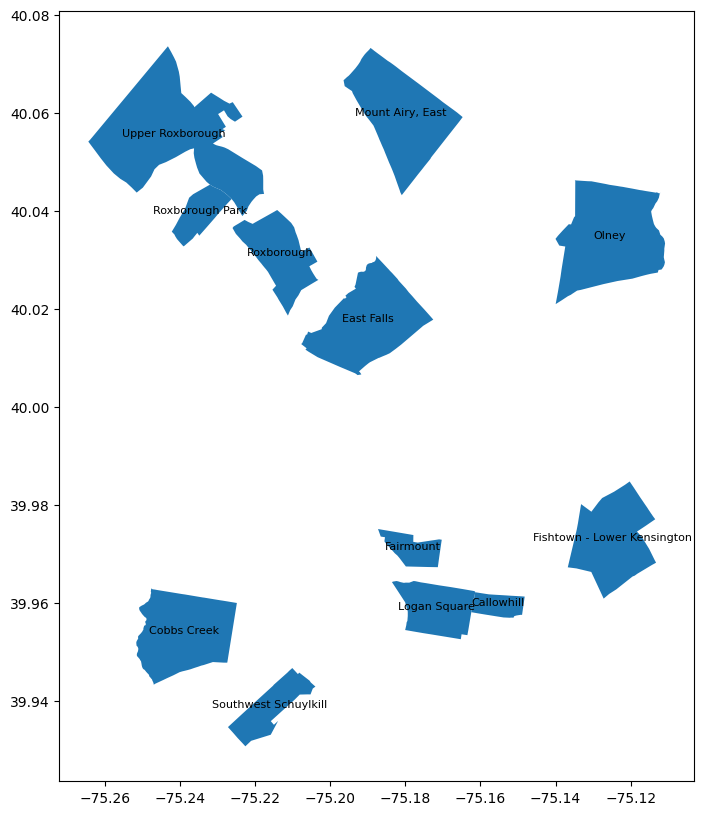

In [10]:
ax = gentrified.geometry.plot(figsize=(10, 10))

# add labels
for idx, row in gentrified.iterrows():
    ax.annotate(
        text=row["LISTNAME"],  
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center',
        fontsize=8
    )

plt.show()

<Axes: >

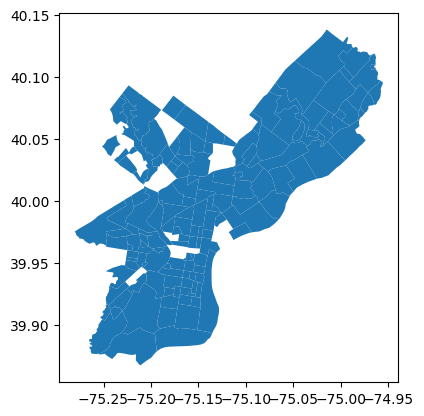

In [11]:
non_gentrified.geometry.plot()

## Add gentrified to yelp data

In [12]:
philly_res = restuarants[(restuarants["city"] == 'Philadelphia') & (restuarants["state"] == 'PA')]
philly_res.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,geometry
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",POINT (-75.15556 39.95551)
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",POINT (-75.14323 39.95395)
19,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",POINT (-75.16257 39.94322)
28,QdN72BWoyFypdGJhhI5r7g,Bar One,767 S 9th St,Philadelphia,PA,19147,39.939825,-75.157447,4.0,65,0,"{'Smoking': 'u'no'', 'NoiseLevel': 'u'average'...","Cocktail Bars, Bars, Italian, Nightlife, Resta...","{'Monday': '16:0-0:0', 'Tuesday': '16:0-0:0', ...",POINT (-75.15745 39.93982)
31,Mjboz24M9NlBeiOJKLEd_Q,DeSandro on Main,4105 Main St,Philadelphia,PA,19127,40.022466,-75.218314,3.0,41,0,"{'RestaurantsReservations': 'False', 'Caters':...","Pizza, Restaurants, Salad, Soup","{'Tuesday': '17:0-21:30', 'Wednesday': '17:0-1...",POINT (-75.21831 40.02247)


In [13]:
philly = gpd.sjoin(philly_res, neighborhoods[['LISTNAME','geometry', 'gentrified']], how="left", predicate="intersects")
philly.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,geometry,index_right,LISTNAME,gentrified
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",POINT (-75.15556 39.95551),92.0,Chinatown,0.0
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",POINT (-75.14323 39.95395),91.0,Old City,0.0
19,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",POINT (-75.16257 39.94322),103.0,Hawthorne,0.0
28,QdN72BWoyFypdGJhhI5r7g,Bar One,767 S 9th St,Philadelphia,PA,19147,39.939825,-75.157447,4.0,65,0,"{'Smoking': 'u'no'', 'NoiseLevel': 'u'average'...","Cocktail Bars, Bars, Italian, Nightlife, Resta...","{'Monday': '16:0-0:0', 'Tuesday': '16:0-0:0', ...",POINT (-75.15745 39.93982),104.0,Bella Vista,0.0
31,Mjboz24M9NlBeiOJKLEd_Q,DeSandro on Main,4105 Main St,Philadelphia,PA,19127,40.022466,-75.218314,3.0,41,0,"{'RestaurantsReservations': 'False', 'Caters':...","Pizza, Restaurants, Salad, Soup","{'Tuesday': '17:0-21:30', 'Wednesday': '17:0-1...",POINT (-75.21831 40.02247),51.0,Manayunk,0.0


In [ ]:
philly.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'geometry', 'index_right',
       'LISTNAME', 'gentrified'],
      dtype='object')

In [15]:
philly.to_file("modified_data/neigh_reviews_joined.gpkg")

In [16]:
philly.to_csv("modified_data/neigh_reviews_joined.csv")